# DS4DS Exercise Sheet 7

**General Instructions:**

- Review the weekly course material (lectures, readings, slides, etc.) before starting the exercises.
- Complete all assigned exercises independently before the Q&A session.
- Please use Julia Version 1.12.x to ensure compatibility.
- Please only write between the `#--- YOUR CODE STARTS HERE ---#` and `#--- YOUR CODE ENDS HERE ---#` comments.

### Task 1: Non-linear function optimization from scratch

In this task, we will implement our own non-linear optimization algorithm and apply it to the 2D Rosenbrock function. The function is defined by

$$
\begin{align}
    \mathcal{L}(\mathbf{w}) = (a - w_1)^2 + b (w_2 - w_1^2)^2
\end{align}
$$

where $a$ and $b$ are parameters of the function. In the following, the parameters will be set to $a = 1$ and $b = 100$.

### Explanation

The task requires implementing the 2D Rosenbrock function, a classic test problem for optimization algorithms. It is often referred to as the "banana function" due to the shape of its contour lines.

The mathematical definition given is:


$$\mathcal{L}(\mathbf{w}) = (a - w_1)^2 + b(w_2 - w_1^2)^2$$

Where:

* $\mathbf{w}$ is an input vector containing two elements: $[w_1, w_2]$.
* $a$ and $b$ are parameters, with default values $a=1$ and $b=100$.

The function takes a vector as input and returns a single scalar value (the cost). The goal of optimization algorithms is usually to find the vector $\mathbf{w}$ that minimizes this cost function. For the standard parameters $a=1, b=100$, the global minimum is located at $(w_1, w_2) = (1, 1)$, where $\mathcal{L}(\mathbf{w}) = 0$.

#### a) Implement the Rosenbrock function so that the input is a vector $\mathbf{w}$ and it returns the scalar cost function value $\mathcal{L}(\mathbf{w})$. 

In [1]:
def rosenbrock(w, a=1, b=100):
    ### BEGIN SOLUTION
    # Extract the components of the vector w
    w1 = w[0]
    w2 = w[1]
    
    # Calculate the Rosenbrock function value based on the formula
    f_value = (a - w1)**2 + b * (w2 - w1**2)**2
    ### END SOLUTION
    return f_value

#### b) Derive the analytical gradient of the Rosenbrock function and implement it in the function outlined below so that it takes $\mathbf{w}$ as input and returns the gradient $\nabla\mathcal{L}(\mathbf{w})$ of the Rosenbrock function. 

### Analytical Derivation

To find the gradient $\nabla \mathcal{L}(\mathbf{w})$, we need to calculate the partial derivatives of the Rosenbrock function with respect to $w_1$ and $w_2$.

The Rosenbrock function is:


$$\mathcal{L}(w_1, w_2) = (a - w_1)^2 + b(w_2 - w_1^2)^2$$

**1. Partial derivative with respect to $w_1$:**
Using the chain rule:


$$\frac{\partial \mathcal{L}}{\partial w_1} = 2(a - w_1)(-1) + 2b(w_2 - w_1^2)(-2w_1)$$

$$\frac{\partial \mathcal{L}}{\partial w_1} = -2(a - w_1) - 4bw_1(w_2 - w_1^2)$$

**2. Partial derivative with respect to $w_2$:**
Using the chain rule again:


$$\frac{\partial \mathcal{L}}{\partial w_2} = 0 + 2b(w_2 - w_1^2)(1)$$

$$\frac{\partial \mathcal{L}}{\partial w_2} = 2b(w_2 - w_1^2)$$

The gradient is the vector of these partial derivatives:


$$\nabla \mathcal{L}(\mathbf{w}) = \begin{bmatrix} \frac{\partial \mathcal{L}}{\partial w_1} \\ \frac{\partial \mathcal{L}}{\partial w_2} \end{bmatrix}$$

In [2]:
import numpy as np

def rosenbrock_gradient(w, a=1, b=100):
    ### BEGIN SOLUTION
    # Extract the components of the vector w
    w1 = w[0]
    w2 = w[1]
    
    # Calculate the partial derivatives based on the analytical derivation
    dw1 = -2 * (a - w1) - 4 * b * w1 * (w2 - w1**2)
    dw2 = 2 * b * (w2 - w1**2)
    
    # Combine them into a gradient vector
    gradient = np.array([dw1, dw2])
    ### END SOLUTION
    
    return gradient

#### c) Implement the steepest gradient descent rule for updating a parameter vector $\mathbf{w}_{current}$ to $\mathbf{w}_{next}$ in the function provided below. The step size $\eta$ is a parameter of this function. 

### Explanation

The steepest gradient descent algorithm minimizes a function by taking steps in the opposite direction of the gradient. The gradient points in the direction of the steepest ascent (where the function increases the fastest). By moving in the negative gradient direction, we move toward a local minimum.

The mathematical rule for updating the parameter vector $\mathbf{w}$ is:


$$\mathbf{w}_{next} = \mathbf{w}_{current} - \eta \cdot \nabla \mathcal{L}(\mathbf{w}_{current})$$

Where:

* $\mathbf{w}_{current}$ is the current position vector.
* $\eta$ (eta) is the learning rate (or step size), controlling how far we move in the direction of the gradient.
* $\nabla \mathcal{L}(\mathbf{w}_{current})$ is the gradient of the function evaluated at the current position.

In [3]:
def steepest_GD_parameter_update(gradient_function, w_current, eta):
    ### BEGIN SOLUTION
    # 1. Calculate the gradient at the current position
    current_gradient = gradient_function(w_current)
    
    # 2. Apply the steepest descent update rule
    # Subtract the scaled gradient from the current weights
    w_next = w_current - eta * current_gradient
    ### END SOLUTION
    
    return w_next

#### d) Implement the entire steepest descent method using the functions from the previous tasks using the template outlined below.

In [4]:
def steepest_GD(f, grad_f, w_init, eta, max_iters=1000, tolerance=1e-5):
    """Steepest gradient descent implementation.
    
    Args:
        f: The function to be optimized
        grad_f: The analytical gradient of the function to be optimized
        w_init: The initial condition at which the optimization algorithm starts
        eta: The learning rate (here, the value is to be a constant during optimization)
        max_iters: A cap for the count of iterations
        tolerance: the tolerance value when the algorithm is terminated because the norm of the difference between 
                   the old and new point is too small
                   
    Returns:
        w_opt: The end value of the optimization
    """
    
    ### BEGIN SOLUTION
    # Ensure the initial weights are a numpy array of floats
    w_current = np.array(w_init, dtype=float)
    
    for i in range(max_iters):
        # 1. Calculate the gradient at the current position
        current_gradient = grad_f(w_current)
        
        # 2. Compute the next position using the steepest descent rule
        w_next = w_current - eta * current_gradient
        
        # 3. Check for convergence using the 2-norm (Euclidean distance)
        step_size = np.linalg.norm(w_next - w_current)
        
        # 4. Update current position for the next iteration
        w_current = w_next
        
        # Break early if the step size is smaller than the tolerance
        if step_size < tolerance:
            break
            
    # Assign the final position to the output variable
    w_opt = w_current
    ### END SOLUTION
    
    return w_opt

#### e) Add a backtracking mechanism for selecting a step size that satisfies the Armijo condition. Hence, start with eta_init = 1 and then reduce it by a factor of 2 until the Armijo condition is satisfied. 

### Explanation

This task introduces a more advanced version of gradient descent. In the previous version, we used a constant learning rate (`eta`). If `eta` is too large, the algorithm might bounce back and forth across the "valley" of the function (like the Rosenbrock function) and never converge. If `eta` is too small, it will take forever to reach the minimum.

To fix this, we use a **Backtracking Line Search** to dynamically adjust the step size at every iteration, ensuring we take the largest possible step that still guarantees a "sufficient decrease" in the function's value.

This condition for sufficient decrease is called the **Armijo Condition**.

The Armijo condition is satisfied when:


$$f(\mathbf{w} - \eta \nabla f(\mathbf{w})) \leq f(\mathbf{w}) - \alpha \eta \|\nabla f(\mathbf{w})\|^2$$

Where:

* $\mathbf{w}$ is the current position (`w_current`).
* $\eta$ is the proposed step size (`eta`).
* $\nabla f(\mathbf{w})$ is the gradient at the current position.
* $\alpha$ is a small constant (often $0.3$, as given in the template) that dictates how much of a decrease we demand.

**The Algorithm:**

1. Start with an initial large step size (`eta_init = 1`).
2. Check if the Armijo condition is met.
3. If not, shrink the step size by multiplying it by $\beta$ (e.g., reduce it by a factor of 2, so $\beta=0.5$).
4. Repeat steps 2 and 3 until the condition is met.

In [5]:
def backtracking_line_search(f, grad_f, w_current, eta_init, alpha=0.3, beta=0.5):
    """
    Finds a step size (eta) that satisfies the Armijo condition.
    """
    ### BEGIN SOLUTION
    eta = eta_init
    current_gradient = grad_f(w_current)
    
    # Calculate the current function value f(w)
    f_current = f(w_current)
    
    # Calculate the squared norm of the gradient
    grad_norm_sq = np.dot(current_gradient, current_gradient)
    
    # Loop until the Armijo condition is satisfied
    while True:
        # Calculate the proposed new position
        w_next_proposed = w_current - eta * current_gradient
        
        # Calculate the function value at the proposed position
        f_next_proposed = f(w_next_proposed)
        
        # Check the Armijo condition
        # f(w_next) <= f(w_current) - alpha * eta * ||grad_f||^2
        if f_next_proposed <= f_current - alpha * eta * grad_norm_sq:
            # Condition met, break the loop and return this eta
            break
        else:
            # Condition not met, reduce the step size by factor beta
            eta = eta * beta
            
    ### END SOLUTION
    return eta


def gradient_descent_backtracking(f, grad_f, w_init, eta_init=1, max_iters=1000, tolerance=1e-5):
    """
    Gradient descent algorithm utilizing backtracking line search for the step size.
    """
    ### BEGIN SOLUTION
    w_current = np.array(w_init, dtype=float)
    
    for i in range(max_iters):
        # 1. Calculate the gradient at the current position
        current_gradient = grad_f(w_current)
        
        # 2. Find the optimal step size for this iteration using backtracking
        eta = backtracking_line_search(f, grad_f, w_current, eta_init)
        
        # 3. Compute the next position using the optimal step size
        w_next = w_current - eta * current_gradient
        
        # 4. Check for convergence using the 2-norm
        step_size = np.linalg.norm(w_next - w_current)
        
        # 5. Update current position
        w_current = w_next
        
        # Break early if converged
        if step_size < tolerance:
            break
            
    w_opt = w_current
    ### END SOLUTION
    
    return w_opt

In [6]:
# Start at a notoriously tricky starting point for the Rosenbrock function
w_start = [-1.2, 1.0]

print(f"Starting position: {w_start}")
print(f"Initial Loss:      {rosenbrock(w_start):.6f}\n")

# Run the optimization
w_opt = gradient_descent_backtracking(
    f=rosenbrock, 
    grad_f=rosenbrock_gradient, 
    w_init=w_start, 
    eta_init=1.0, 
    max_iters=5000, 
    tolerance=1e-6
)

# Print the results
print(f"Optimized weights: [w1, w2] = [{w_opt[0]:.6f}, {w_opt[1]:.6f}]")
print(f"Final Loss:        {rosenbrock(w_opt):.6f}")
print(f"Expected minimum:  [1.000000, 1.000000]")

Starting position: [-1.2, 1.0]
Initial Loss:      24.200000

Optimized weights: [w1, w2] = [1.000429, 1.000860]
Final Loss:        0.000000
Expected minimum:  [1.000000, 1.000000]


### Task 2: Fitting a surrogate model to geodata 

In this task, we are given a dataset of the geodata of north-western Germany and some parts of adjacent European countries. 
The dataset (obtained from [here](https://gdz.bkg.bund.de/index.php/default/digitale-geodaten/geodaetische-basisdaten/quasigeoid-der-bundesrepublik-deutschland-quasigeoid.html)) 
consists of a large number of points with two positions (longitude and latitude; $\mathbf{z} \in \mathbb{R}^2$) and an associated height value ($y \in \mathbb{R}$).

<img src="./approximate_map_area.png" alt="height_map" width="400"/>  <img src="./surface_top.svg" alt="data_height_map" width="400"/> <img src="./surface_front.svg" alt="data_height_map" width="400"/>

Source for topographic map (left-most image): https://de-de.topographic-map.com/map-95z57/Deutschland/

(There is some extrapolation issues at the sides of the plots, but these are not present in the data itself)

---

Your task is to fit a set of $q$ (slightly modified) radial basis functions (RBFs) to the data

$$
\begin{align}
    h(\mathbf{z}, \mathbf{w}) &= \sum_{i=1}^q \mathrm{RBF}(\mathbf{z}, \mathbf{w}_i) \\
    &=  \sum_{i=1}^q w_{i, 1} \cdot \exp\left( - \exp(w_{i, 2}) \cdot \left\| \begin{bmatrix} z_{1} \\ z_{2} \end{bmatrix} - \begin{bmatrix} w_{i, 3} \\ w_{i, 4} \end{bmatrix} \right\|_2^2\right),
\end{align}
$$

parameterized by $q$ parameter vectors $\mathbf{w}_i = \begin{bmatrix} w_{i, 1} \\ w_{i, 2} \\ w_{i, 3} \\ w_{i, 4} \end{bmatrix}$ for $i \in 1,\dots,q$ and the total (flattened) parameter vector $\mathbf{w}$ 

$$
\begin{align}
    \mathbf{w} = \begin{bmatrix} w_{1, 1} \\ w_{1, 2} \\  w_{1, 3} \\ \vdots \\ w_{q, 2} \\ w_{q, 3} \\ w_{q, 4} \\ \end{bmatrix}.
\end{align}
$$

### The Concept: Radial Basis Functions (RBFs)

A **Radial Basis Function (RBF)** is a mathematical function whose value depends primarily on the distance between an input point and a fixed center point. Think of it as a localized "bump" or "hill" on a map. By adding many of these bumps together (each with different heights, widths, and locations), you can approximate complex 3D surfaces—like the elevation map of Germany shown.

Let's break down the specific components of the modified RBF formula:


$$\text{RBF}(\mathbf{z}, \mathbf{w}_i) = w_{i,1} \cdot \exp\left( - \exp(w_{i,2}) \cdot \left\| \begin{bmatrix} z_1 \\ z_2 \end{bmatrix} - \begin{bmatrix} w_{i,3} \\ w_{i,4} \end{bmatrix} \right\|_2^2 \right)$$

Here is what each parameter in the vector $\mathbf{w}_i = [w_{i,1}, w_{i,2}, w_{i,3}, w_{i,4}]^T$ controls:

* **$w_{i,1}$ (Amplitude/Weight):** This controls the height of the bump. If it's negative, it becomes a dip instead of a hill.
* **$w_{i,2}$ (Spread/Width Modifier):** This dictates how wide or narrow the bump is. The formula uses $\exp(w_{i,2})$ as a clever mathematical trick. Because the exponential function always returns a positive number, it guarantees that the width parameter remains strictly positive during optimization, preventing the optimization algorithm from crashing or producing non-sensical inverted shapes.
* **$[w_{i,3}, w_{i,4}]^T$ (Center):** These are the coordinates (longitude and latitude) indicating exactly where the peak of the bump is located on the map.
* **$\| \mathbf{z} - \text{center} \|_2^2$:** This is the squared Euclidean distance between the evaluation point $\mathbf{z}$ and the center of the RBF.

The ultimate goal here is to combine a set of $q$ of these RBFs to build our complete surrogate model:


$$h(\mathbf{z}, \mathbf{w}) = \sum_{i=1}^q \text{RBF}(\mathbf{z}, \mathbf{w}_i)$$

To do this, we will likely need to:

1. Create a function that sums up multiple RBFs given a flattened parameter vector $\mathbf{w}$.
2. Define a loss function (like Mean Squared Error) to compare our RBF model's predicted heights to the actual true heights in the dataset.
3. Calculate the gradient of that loss function so we can train it.
4. Unleash the backtracking gradient descent optimizer to find the perfect parameters!

In engineering and mathematics, a **surrogate model** (sometimes called a proxy model or emulator) is a simplified mathematical approximation of a much more complex, unknown, or computationally expensive system.

Think of it as a "stand-in" or a "body double."

If evaluating the true system takes too much time, money, or computing power—or if the true mathematical equation simply doesn't exist—we build a surrogate model that behaves *almost exactly* like the true system but is incredibly fast and easy to calculate.

### Surrogate Models in the Context of Geodata Task

To understand why we are building one right now, let's look at our geodata task:

* **The True System:** The actual physical elevation of the Earth across Germany. There is no single, elegant mathematical equation like $y = x^2$ that describes the topography of the Earth. You just have a massive dataset of millions of discrete coordinates and their corresponding height measurements.
* **The Problem:** If you want to know the elevation at a very specific coordinate (say, exactly halfway between two known data points), or if you want to run simulations (like water runoff or wind patterns), querying a massive database of discrete points is slow, clunky, and doesn't give you a continuous, smooth surface to work with.
* **The Surrogate Model:** Your sum of Radial Basis Functions ($h(\mathbf{z}, \mathbf{w}) = \sum \text{RBF}$).

By using our optimization algorithm to adjust the weights, widths, and centers of these $q$ different "bumps" (RBFs), we are forcing this math equation to mimic the true terrain of Germany.

### Why is this useful?

Once our optimization is finished and we have found the perfect parameter vector $\mathbf{w}$, we can throw away the massive, heavy dataset of raw geodata.

Instead, we just keep our surrogate equation $h(\mathbf{z}, \mathbf{w})$.

1. **It is extremely fast:** Calculating the sum of a few exponential functions takes a fraction of a millisecond.
2. **It is continuous:** We can plug in *any* coordinate on the map, and it will interpolate a smooth, highly accurate estimate of the height.
3. **It is mathematically nice:** Because it is made of standard math functions (exponentials), we can easily calculate its gradient or integral, which is impossible to do directly on raw scattered data points.

In short, we are teaching a simple math equation how to "memorize and mimic" the shape of a country!


##### **a)** Implement a single $\mathrm{RBF}(\mathbf{z}, \mathbf{w}_i)$ that takes $\mathbf{z}$ and the parameter vector $\mathbf{w}_i$ with four elements as input.

In [7]:
import numpy as np

def RBF(z, w_i):
    ### BEGIN SOLUTION
    # Extract the components of the input coordinate z
    z1, z2 = z[0], z[1]
    
    # Extract the 4 parameters from the parameter vector w_i
    w1, w2, w3, w4 = w_i[0], w_i[1], w_i[2], w_i[3]
    
    # 1. Calculate the squared Euclidean distance between z and the center [w3, w4]
    sq_distance = (z1 - w3)**2 + (z2 - w4)**2
    
    # Alternatively, you could use numpy's built-in norm:
    # center = np.array([w3, w4])
    # sq_distance = np.linalg.norm(z - center)**2
    
    # 2. Compute the final RBF value according to the formula
    f_value = w1 * np.exp(-np.exp(w2) * sq_distance)
    ### END SOLUTION
    
    return f_value

##### **b)** Create a model $h(\mathbf{z}, \mathbf{w})$ that consists of a sum of $q$ RBF functions parameterized by a vector $\mathbf{w}$ with $4 \cdot q$ elements.

### The Concept: Building the Surrogate Model

In the previous task, we built a single Radial Basis Function (RBF) representing one "bump" on the map. However, one bump isn't enough to model the complex topography of Germany.

We need to combine $q$ of these bumps together. The function $h(\mathbf{z}, \mathbf{w})$ simply loops over all $q$ bumps, calculates the height of each bump at the specific coordinate $\mathbf{z}$, and adds them all up.

**Handling the Parameter Vector ($\mathbf{w}$):**
Because most optimization algorithms (like the gradient descent one we built) expect a single, flat 1D array of parameters to optimize, all the parameters for all $q$ RBFs are glued together into one long vector $\mathbf{w}$.

* Since each RBF needs 4 parameters ($w_1, w_2, w_3, w_4$), the total length of $\mathbf{w}$ will be $4 \times q$.
* To evaluate the $i$-th RBF, we just "slice" out its specific 4 parameters from the long vector. For example, the parameters for the 1st RBF are at indices `0` to `3`, the 2nd RBF at `4` to `7`, and so on.

---

In [8]:
def h(z, w, q):
    # Sanity check to ensure our parameter vector length matches q
    assert len(w) == q * 4, "Invalid number of parameters."
    
    ### BEGIN SOLUTION
    f_value = 0.0
    
    # Loop over all q RBFs
    for i in range(q):
        # Slice out the 4 parameters for the current RBF
        # i*4 is the start index, (i+1)*4 is the end index (exclusive)
        w_i = w[i*4 : (i+1)*4]
        
        # Calculate the value of this specific RBF and add it to the total sum
        f_value += RBF(z, w_i)
        
    ### END SOLUTION
    
    return f_value

##### **c)** Provide a function for the symbolic gradient of the RBF w.r.t. the weights, i.e., $\nabla_{\mathbf{w}} \mathrm{RBF}(\mathbf{z}, \mathbf{w})$.

### Analytical Derivation

To write the gradient function, we first need to calculate the partial derivatives of the RBF with respect to each of the four parameters in $\mathbf{w}_i = [w_1, w_2, w_3, w_4]^T$.

Recall the formula for a single RBF:


$$\text{RBF}(\mathbf{z}, \mathbf{w}_i) = w_1 \cdot \exp\left( - \exp(w_2) \cdot \left( (z_1 - w_3)^2 + (z_2 - w_4)^2 \right) \right)$$

To make the derivation easier to read, let's define two intermediate variables:

* The squared distance: $S = (z_1 - w_3)^2 + (z_2 - w_4)^2$
* The exponential term (which is exactly the RBF value without $w_1$): $u = \exp(-\exp(w_2) \cdot S)$

So our function is simply $f = w_1 \cdot u$. Now, let's find the derivatives using the chain rule:

**1. Derivative w.r.t $w_1$ (Amplitude):**


$$\frac{\partial f}{\partial w_1} = u$$

**2. Derivative w.r.t $w_2$ (Spread modifier):**


$$\frac{\partial f}{\partial w_2} = w_1 \cdot \frac{\partial u}{\partial w_2} = w_1 \cdot u \cdot \left( -\exp(w_2) \cdot S \right) = -w_1 \cdot \exp(w_2) \cdot S \cdot u$$

**3. Derivative w.r.t $w_3$ (X-Center):**


$$\frac{\partial f}{\partial w_3} = w_1 \cdot \frac{\partial u}{\partial w_3} = w_1 \cdot u \cdot \left( -\exp(w_2) \cdot \frac{\partial S}{\partial w_3} \right)$$


Since $\frac{\partial S}{\partial w_3} = -2(z_1 - w_3)$:


$$\frac{\partial f}{\partial w_3} = 2 \cdot w_1 \cdot \exp(w_2) \cdot (z_1 - w_3) \cdot u$$

**4. Derivative w.r.t $w_4$ (Y-Center):**
Following the exact same logic as $w_3$:


$$\frac{\partial f}{\partial w_4} = 2 \cdot w_1 \cdot \exp(w_2) \cdot (z_2 - w_4) \cdot u$$

In [9]:
def gradient_RBF(z, w_i):
    ### BEGIN SOLUTION
    # Extract coordinates and parameters
    z1, z2 = z[0], z[1]
    w1, w2, w3, w4 = w_i[0], w_i[1], w_i[2], w_i[3]
    
    # Pre-compute shared intermediate terms to save computation time
    S = (z1 - w3)**2 + (z2 - w4)**2
    E = np.exp(w2)
    u = np.exp(-E * S)
    
    # Calculate the partial derivatives using the derived formulas
    dw1 = u
    dw2 = -w1 * E * S * u
    dw3 = 2 * w1 * E * (z1 - w3) * u
    dw4 = 2 * w1 * E * (z2 - w4) * u
    
    # Combine into a gradient vector
    gradient = np.array([dw1, dw2, dw3, dw4])
    ### END SOLUTION
    
    return gradient

##### **d)** Provide a function for the gradient of the sum of $q$ RBF functions 
w.r.t. the weight vector $\mathbf{w}$, i.e., $\nabla_{\mathbf{w}} h(\mathbf{z}, \mathbf{w})$.

### The Concept: Gradient of a Sum

The mathematical principle here relies on two simple rules of calculus:

1. **The Sum Rule:** The derivative of a sum is the sum of the derivatives.
2. **Independent Variables:** Each individual RBF bump $\text{RBF}_i$ *only* depends on its own 4 specific parameters ($\mathbf{w}_i$). It does not care about the parameters of any other bump ($\mathbf{w}_j$). Therefore, the partial derivative of $\text{RBF}_i$ with respect to the parameters of $\text{RBF}_j$ is exactly $0$.

Because of this, the full gradient vector $\nabla_{\mathbf{w}} h(\mathbf{z}, \mathbf{w})$ is simply the individual 4-element gradients stacked (concatenated) end-to-end.

If we have $q$ RBFs, our full gradient will be a flat array of length $4 \times q$. To build it, we just loop through our parameters, calculate the 4-element gradient for each RBF using the `gradient_RBF` function from your previous task, and slot those 4 numbers into the correct position in the full gradient array.

---

In [10]:
def gradient_h(z, w, q):
    # Sanity check to ensure our parameter vector length matches q
    assert len(w) == q * 4, "Invalid number of parameters."
    
    ### BEGIN SOLUTION
    # Initialize an array of zeros for the full gradient (length 4*q)
    gradient = np.zeros(len(w))
    
    # Loop over all q RBFs
    for i in range(q):
        # Slice out the 4 parameters for the current RBF
        w_i = w[i*4 : (i+1)*4]
        
        # Calculate the 4-element gradient for this specific RBF
        grad_i = gradient_RBF(z, w_i)
        
        # Insert these 4 gradient values into the correct slice of the full gradient vector
        gradient[i*4 : (i+1)*4] = grad_i
        
    ### END SOLUTION
    
    return gradient

##### **e)** In order to assess the model quality, we want to compare the mean squared error (MSE) between the data $y[k]$ and the prediction made by the trained model $y_{est}[k] = h(\mathbf{z}[k], \mathbf{w})$. Implement this function into the template below. $\mathbf{y}$ is the vector containing all elements of $y[k]$, i.e.,

$$
\begin{align}
    \mathbf{y} = \begin{bmatrix} y[1] \\ y[2] \\ \vdots \\ y[N] \end{bmatrix}
\end{align}
$$


and $\mathbf{Z}$ is a Matrix containing all $\mathbf{z}[k]$, i.e.,

$$
\begin{align}
    \mathbf{Z} = \begin{bmatrix} \mathbf{z}[1] \\ \mathbf{z}[2] \\ \vdots \\ \mathbf{z}[N] \end{bmatrix}
\end{align}.
$$

### The Concept: Mean Squared Error (MSE)

To train our surrogate model, we need a way to measure how "wrong" its current guesses are. The Mean Squared Error (MSE) is the standard tool for this.

Here is how it works:

1. **Iterate through the data:** We look at every single coordinate point $\mathbf{z}[k]$ in our dataset $\mathbf{Z}$. (There are $N$ total points).
2. **Make a prediction:** We use our current surrogate model $h(\mathbf{z}[k], \mathbf{w})$ to guess what the height should be at that coordinate. We'll call this guess $y_{est}[k]$.
3. **Calculate the error:** We subtract our guess from the actual true height $y[k]$ to find the error for that point.
4. **Square the error:** We square the error $(y[k] - y_{est}[k])^2$. This does two things: it makes all errors positive (so a guess that is too high doesn't cancel out a guess that is too low), and it heavily penalizes really bad guesses.
5. **Average them out:** We sum up all the squared errors and divide by the total number of points $N$ to get the *mean* (average) error.

The mathematical formula is:


$$\text{MSE} = \frac{1}{N} \sum_{k=1}^N (y[k] - h(\mathbf{z}[k], \mathbf{w}))^2$$

There is no single "magic number" for $q$. In machine learning and surrogate modeling, $q$ is what we call a **hyperparameter**—a setting you must choose *before* you run your optimization.

The choice of $q$ dictates the **capacity** of your model (how complex of a shape it can memorize). Choosing it involves a classic machine learning balancing act known as the Bias-Variance Tradeoff:

### 1. Too Low (e.g., $q = 1$ to $5$) $\rightarrow$ Underfitting

If you use only a few RBFs, your model is too simple. It might figure out broad trends (like "the Alps in the south are higher than the coast in the north"), but it won't have enough "bumps" to fill in the local details. Your Mean Squared Error (MSE) will remain high no matter how long you train it.

### 2. Too High (e.g., $q = 1000+$) $\rightarrow$ Overfitting & Computational Doom

If you use a massive number of RBFs, your model becomes overly flexible.

* **The Math Problem:** It might start fitting to the *noise* in your data rather than the actual terrain, resulting in a jagged, unrealistic surface.
* **The Compute Problem:** Remember that your total parameter vector $\mathbf{w}$ has $4 \times q$ elements. If $q=1000$, your gradient descent algorithm has to calculate the partial derivatives and take steps in a **4,000-dimensional space**. In Python, calculating this for every data point at every iteration could take hours or days to run.

### 3. The "Goldilocks" Zone

You want the lowest $q$ that gives you an acceptable MSE.

In [11]:
def MSE_loss(y, Z, w, q):
    ### BEGIN SOLUTION
    # Get the total number of data points N
    N = len(y)
    
    # Initialize the sum of squared errors
    sse = 0.0
    
    # Loop over all N data points
    for k in range(N):
        # The true height at point k
        y_true = y[k]
        
        # The coordinate at point k (z1, z2)
        # Z is usually shape (N, 2) in this context
        z_k = Z[k, :] 
        
        # Predict the height using our surrogate model
        y_est = h(z_k, w, q)
        
        # Calculate the squared error and add it to our sum
        error = y_true - y_est
        sse += error**2
        
    # Calculate the mean by dividing the sum by N
    mse = sse / N
    ### END SOLUTION
    
    return mse

##### **f)** Provide a function that determines the gradient of the MSE loss w.r.t. the parameter vector $\mathbf{w}$, i.e., $\nabla_{\mathbf{w}} \mathrm{MSE}(\mathbf{y}, \mathbf{Z}, \mathbf{w})$. You may reuse the functions you introduced in previous subtasks.

### The Concept: Gradient of the Mean Squared Error

To train the surrogate model using gradient descent, we need to know the gradient of the entire loss function (MSE) with respect to our parameter vector $\mathbf{w}$.

Let's derive this mathematically. Recall the MSE formula from the previous task:


$$\text{MSE}(\mathbf{w}) = \frac{1}{N} \sum_{k=1}^N (y[k] - h(\mathbf{z}[k], \mathbf{w}))^2$$

To find the gradient $\nabla_{\mathbf{w}}\text{MSE}(\mathbf{w})$, we apply the chain rule to the squared term:

1. The derivative of the outside (the square): $2 \cdot (y[k] - h(\mathbf{z}[k], \mathbf{w}))$
2. The derivative of the inside (the prediction error): $0 - \nabla_{\mathbf{w}} h(\mathbf{z}[k], \mathbf{w})$

Putting it together and keeping the sum and the $\frac{1}{N}$ scaling factor:


$$\nabla_{\mathbf{w}}\text{MSE}(\mathbf{w}) = \frac{1}{N} \sum_{k=1}^N 2 \cdot (y[k] - h(\mathbf{z}[k], \mathbf{w})) \cdot (-\nabla_{\mathbf{w}} h(\mathbf{z}[k], \mathbf{w}))$$

Rearranging the negative sign makes it a bit cleaner:


$$\nabla_{\mathbf{w}}\text{MSE}(\mathbf{w}) = -\frac{2}{N} \sum_{k=1}^N \underbrace{(y[k] - h(\mathbf{z}[k], \mathbf{w}))}_{\text{Error}} \cdot \underbrace{\nabla_{\mathbf{w}} h(\mathbf{z}[k], \mathbf{w})}_{\text{Model Gradient}}$$

**What does this mean intuitively?**
For every data point, we check how wrong our prediction is (the Error). We multiply that error by the gradient of our RBF model (`gradient_h` from Task d).

* If the error is huge, we take a huge step in the direction of the gradient to fix it.
* If the error is close to 0, we barely touch the parameters for that point.
We add up these adjustments for every single data point on the map and average them out by dividing by $N$.

In [12]:
def gradient_MSE_loss(y, Z, w, q):
    ### BEGIN SOLUTION
    # Get the total number of data points N
    N = len(y)
    
    # Initialize an empty gradient vector of the same shape as w
    gradient = np.zeros(len(w))
    
    # Loop over all N data points
    for k in range(N):
        # Extract the true height and coordinate for point k
        y_k = y[k]
        z_k = Z[k, :] 
        
        # 1. Calculate the prediction y_est
        y_est = h(z_k, w, q)
        
        # 2. Calculate the error (y - y_est)
        error = y_k - y_est
        
        # 3. Get the gradient of the surrogate model w.r.t w
        grad_h_k = gradient_h(z_k, w, q)
        
        # 4. Accumulate the MSE gradient for this point using the chain rule formula
        gradient += -2.0 * error * grad_h_k
        
    # Average the accumulated gradient by dividing by N
    gradient = gradient / N
    ### END SOLUTION
    
    return gradient

##### Loading and preparing the dataset

In [13]:
def load_dataset():
    ### load and prepare the data set
    # np.loadtxt is the standard way to read space/tab delimited text files
    X = np.loadtxt("./GCG2016_WE.txt", dtype=np.float64)
    
    # 1. Find valid data points (where the height/3rd column is < 1e3)
    # Note: Python is 0-indexed, so the 3rd column is index 2!
    valid_mask = X[:, 2] < 1e3
    
    # Extract the valid positions (Z) and heights (y) using the mask
    Z = X[valid_mask, 0:2]
    y = X[valid_mask, 2]
    
    # 2. Subsample the data by taking every 50th point
    # The syntax [start:stop:step] is used here
    Z = Z[0::50, :]
    y = y[0::50]
    N = len(y)
    
    print("Size of the final data set: ")
    print(N)
    
    # 3. Min-Max Normalization helper function
    def min_max_normalization(a):
        a_max = np.max(a)
        a_min = np.min(a)
        # This formula normalizes the array to the range [-1, 1]
        return (a - a_min) / (a_max - a_min) * 2 - 1
        
    # 4. Normalize the target heights
    y = min_max_normalization(y)
    
    # 5. Normalize the coordinates independently
    Z_1 = min_max_normalization(Z[:, 0])
    Z_2 = min_max_normalization(Z[:, 1])
    
    # hcat (horizontal concatenation) equivalent in NumPy
    Z = np.column_stack((Z_1, Z_2))
    
    return Z, y, N

# Execute the function
Z, y, N = load_dataset()

Size of the final data set: 
2832


##### **g)** Use the standard gradient descent algorithm to fit a model with $q=100$ RBFs to the entire data set (use your own implementation, do not use the ```Optim```-package in this task). Run for $200$ iterations (without early termination) with step-length $\eta=3$ and use the given initial conditions $\mathbf{w}_0$ to initialize your algorithm.

Report on the MSE between the RBF model and the data set in each iteration of the algorithm (exactly $201$ loss values where the first one is from the initial guess and the last one is from after the last iteration). 

### Explanation

This is the grand finale where everything comes together. We are going to use the **Standard Gradient Descent** algorithm to fit $q=100$ RBFs to our geodata.

The assignment requires us to:

1. Translate the `compute_initial_position(q)` function to initialize our 100 RBFs evenly across the map.
2. Run standard gradient descent for exactly 200 iterations with a fixed learning rate of $\eta = 3$.
3. Record the MSE loss at the very beginning (iteration 0) and after every single step, resulting in a list of 201 loss values.

In [14]:
# 1. Translate the initialization function
def compute_initial_position(q):
    # Calculate the grid size (sqrt of q)
    grid_size = int(np.sqrt(q))
    
    # Create linearly spaced coordinates between -1 and 1
    x_ = np.linspace(-1, 1, grid_size)
    y_ = np.linspace(-1, 1, grid_size)
    
    # Create a 2D meshgrid of all combinations
    X, Y = np.meshgrid(x_, y_)
    
    # Flatten the grids into column vectors
    grid_X = X.flatten()
    grid_Y = Y.flatten()
    
    # Initialize the parameters for all q RBFs
    # w1 (amplitude): start small at 0.05
    w1 = np.ones(q) * 0.05 
    # w2 (spread): start at 3.4
    w2 = np.ones(q) * 3.4
    # w3 (x-center): from the grid
    w3 = grid_X
    # w4 (y-center): from the grid
    w4 = grid_Y
    
    # Stack them together into a (q, 4) matrix
    w_matrix = np.column_stack((w1, w2, w3, w4))
    
    # Flatten the entire matrix into a 1D array of length 4*q
    w0 = w_matrix.flatten()
    
    return w0

In [15]:
# 2. Setup the optimization parameters
q = 100
w0 = compute_initial_position(q)

# Load the dataset (Make sure you ran the load_dataset block from the previous step)
Z, y, N = load_dataset()

max_n_iterations = 200
eta = 3
# Initialize the array to store 201 loss values
loss_values = np.zeros(max_n_iterations + 1)

### BEGIN SOLUTION
# Start with our initial guess
w_current = w0.copy()

# Calculate and store the initial loss (before any steps are taken)
initial_loss = MSE_loss(y, Z, w_current, q)
loss_values[0] = initial_loss
print(f"Iteration 000 | Loss: {initial_loss:.6f}")

# Run standard gradient descent loop
for i in range(max_n_iterations):
    # 1. Calculate the gradient of the MSE loss at the current position
    # (This uses the gradient_MSE_loss function from task f)
    current_gradient = gradient_MSE_loss(y, Z, w_current, q)
    
    # 2. Take a step in the opposite direction of the gradient
    # w_next = w_current - eta * gradient
    w_next = w_current - eta * current_gradient
    
    # 3. Calculate the new loss at this updated position
    current_loss = MSE_loss(y, Z, w_next, q)
    
    # 4. Store the loss in the array (offset by 1 because index 0 is the initial guess)
    loss_values[i + 1] = current_loss
    
    # 5. Update w_current for the next iteration
    w_current = w_next
    
    # Optional: Print progress every 20 iterations
    if (i + 1) % 20 == 0:
        print(f"Iteration {i+1:03d} | Loss: {current_loss:.6f}")

# Assign the final optimized weights to w_opt for the plotting script
w_opt = w_current
### END SOLUTION

Size of the final data set: 
2832
Iteration 000 | Loss: 0.353564
Iteration 020 | Loss: 0.002069
Iteration 040 | Loss: 0.000896
Iteration 060 | Loss: 0.000587
Iteration 080 | Loss: 0.000453
Iteration 100 | Loss: 0.000379
Iteration 120 | Loss: 0.000331
Iteration 140 | Loss: 0.000296
Iteration 160 | Loss: 0.000270
Iteration 180 | Loss: 0.000249
Iteration 200 | Loss: 0.000232


Code for the plotting of the data and your results is provided in the following cell. 

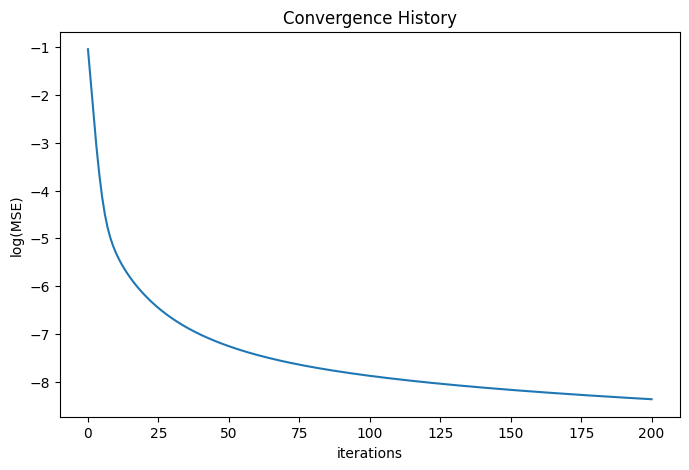

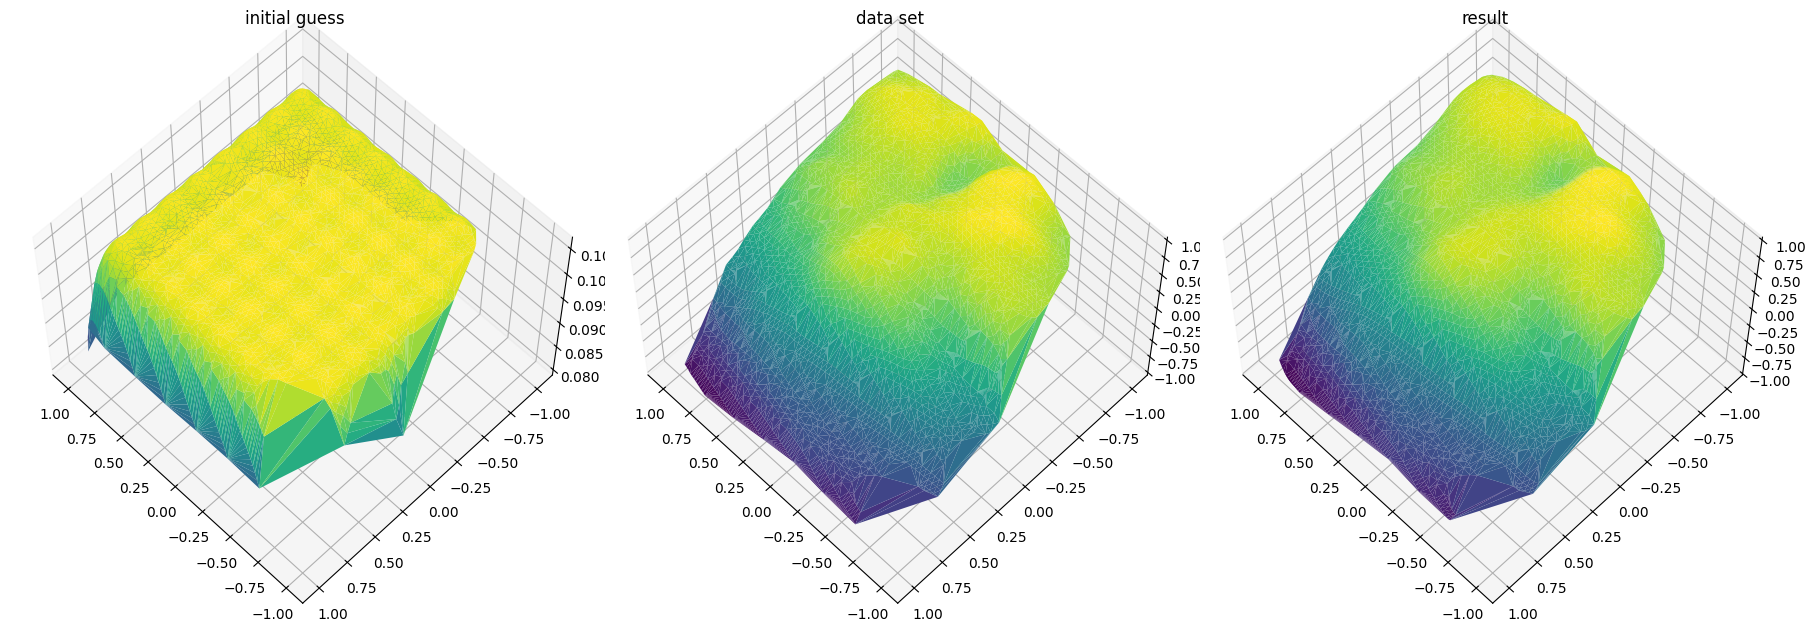

In [16]:
import matplotlib.pyplot as plt

# Assuming loss_values, Z, y, w0, w_opt, and q are already defined in your environment

# 1. Plot the loss curve
plt.figure(figsize=(8, 5))
# Plot the log of the loss values
plt.plot(np.log(loss_values))
plt.xlabel("iterations")
plt.ylabel("log(MSE)") 
plt.title("Convergence History")
plt.show()

# 2. Calculate the predictions for all data points
# We use list comprehensions to mimic the Julia syntax: [h(z, w, q) for z in Z]
y_init = np.array([h(Z[k, :], w0, q) for k in range(Z.shape[0])])
y_est = np.array([h(Z[k, :], w_opt, q) for k in range(Z.shape[0])])

# Extract X and Y coordinates for plotting (accounting for Python's 0-based indexing)
X_coords = Z[:, 1]
Y_coords = Z[:, 0]

# 3. Create a wide figure to hold our 3 side-by-side surface plots
fig = plt.figure(figsize=(18, 6))

# Subplot 1: Initial Guess
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_trisurf(X_coords, Y_coords, y_init, cmap='viridis', edgecolor='none')
ax1.view_init(elev=60, azim=135)
ax1.set_title("initial guess")

# Subplot 2: True Data Set
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot_trisurf(X_coords, Y_coords, y, cmap='viridis', edgecolor='none')
ax2.view_init(elev=60, azim=135)
ax2.set_title("data set")

# Subplot 3: Final Optimized Result
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.plot_trisurf(X_coords, Y_coords, y_est, cmap='viridis', edgecolor='none')
ax3.view_init(elev=60, azim=135)
ax3.set_title("result")

plt.tight_layout()
plt.show()

##### Food for thought: 
What is the influence of the parameter $w_{i, 2}$, why would one use $\exp(w_{i, 2})$ instead of simply $w_{i, 2}$ in the RBF?

### The Influence of $w_{i,2}$ (The Spread)

In the Radial Basis Function formula, the parameter $w_{i,2}$ controls the **width, spread, or "radius"** of the bump.

Think of it like adjusting the focus beam of a flashlight:

* A **high** modifier makes the bump very sharp and narrow (a localized spike).
* A **low** modifier makes the bump very wide and smooth (a broad hill).

When fitting a surrogate model, the optimization algorithm adjusts this parameter so that some RBFs cover massive regional features (like a whole mountain range), while others shrink down to capture tiny, high-frequency details (like a single peak).

---

### Why use $\exp(w_{i,2})$ instead of just $w_{i,2}$?

This is a brilliant trick used in machine learning called **Unconstrained Reparameterization**. It is done purely to prevent the gradient descent algorithm from breaking the math.

A standard Gaussian RBF looks like this:


$$f(r) = \exp(-\gamma \cdot r^2)$$


For this to remain a localized "bump," the spread modifier $\gamma$ **must be strictly positive** ($\gamma > 0$).

**What happens if we just use $w_{i,2}$ directly?**
If we just used $w_{i,2}$ and the gradient descent algorithm took a step that accidentally pushed $w_{i,2}$ into negative numbers (e.g., $w_{i,2} = -2$), the formula would become:


$$f(r) = \exp(-(-2) \cdot r^2) = \exp(2 \cdot r^2)$$

Because the negative signs cancel out, the exponent becomes positive. As the distance $r$ increases, $\exp(2 \cdot r^2)$ explodes to infinity. The localized "bump" instantly turns into an infinite, upward-curving bowl. If this happens to even one of your 100 RBFs, your entire surrogate model will collapse, and your MSE loss will shoot to `NaN` or `Infinity`.

**The $\exp()$ Safety Net**
By replacing $\gamma$ with $\exp(w_{i,2})$, we guarantee that the modifier is always positive, no matter what the optimizer does.

* If the optimizer sets $w_{i,2} = 5$, then $\exp(5) \approx 148$ (very narrow bump).
* If the optimizer sets $w_{i,2} = -5$, then $\exp(-5) \approx 0.006$ (very wide bump).

The optimizer is free to explore any number from $-\infty$ to $+\infty$ without ever violating the strict mathematical rules of the RBF.